In [3]:
!pip install gpxpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.2 MB/s eta 0:00:00


In [4]:
import gpxpy
import gpxpy.gpx
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook Overview

This notebook analyzes GPX data from the [Toronto Half Marathon](https://www.racepoint.ca/maps/torontomarathon.html) on May 3rd, 2026 to extract key performance metrics and identify anomalies.

## Sections:

1.  **Load and Prepare GPX Data**: Load GPX data and compute the core metrics used in the analysis, including distance, speed, and elevation change.
2.  **Aggregate Data by Kilometer Segment**: Group the cleaned GPX data into kilometer segments and calculate average speed, total time, and average elevation.
3.  **Detect Speed Anomalies**: Apply the IQR-based box plot method to identify unusually fast or slow segments.
4.  **Visualize Key Performance Metrics**: Plot average speed, elevation, and cumulative time by kilometer segment, highlighting anomalies.
5.  **Interactive Map Visualization of the GPX Track with Anomalies**: Display the route on an interactive map and highlight the anomalous segments geographically.

### Load and Prepare GPX Data

This section loads GPX data and prepares the core features used in the analysis. It calculates time differences, geodesic distances, cumulative distance, speed, and elevation change, then focuses the dataset on the 22-kilometer half-marathon segment.

In [5]:
# --- 1. Define GPX file path and handle file not found ---
# You can upload a GPX file to your Colab environment or specify a URL.
gpx_file_path = 'YOUR_GPX_FILE_PATH'  # Replace with the path to your GPX file

try:
    with open(gpx_file_path, 'r') as gpx_file:
        gpx = gpxpy.parse(gpx_file)
except FileNotFoundError:
    raise FileNotFoundError(f"GPX file not found at {gpx_file_path}. Please provide a real GPX file path.")

print(f"Loaded GPX data with {len(gpx.tracks)} tracks.")


Loaded GPX data with 1 tracks.
Extracted 4983 data points.
DataFrame head (before filtering and feature engineering):
    latitude  longitude  elevation                      time
0  43.767106 -79.412424      176.8 2026-05-03 12:30:06+00:00
1  43.767068 -79.412409      176.8 2026-05-03 12:30:08+00:00
2  43.767041 -79.412401      176.7 2026-05-03 12:30:09+00:00
3  43.767007 -79.412386      176.7 2026-05-03 12:30:10+00:00
4  43.766973 -79.412371      176.7 2026-05-03 12:30:11+00:00

Filtered data from 2026-05-03 12:30:06+00:00 to 2026-05-03 13:53:51+00:00.
Filtered from 4983 to 4977 data points after time filter.
Filtered raw data from 4977 to 4938 points within 22.0 km.

DataFrame with all derived features head:
                       time   latitude  longitude  elevation  time_diff  \
0 2026-05-03 12:30:06+00:00  43.767106 -79.412424      176.8        0.0   
1 2026-05-03 12:30:08+00:00  43.767068 -79.412409      176.8        2.0   
2 2026-05-03 12:30:09+00:00  43.767041 -79.412401      

### Aggregate Data by Kilometer Segment

This section aggregates the cleaned GPX data into one-kilometer segments and calculates average speed, total time, and average elevation for each segment.

In [6]:
print("\n--- Aggregating data by kilometer segments ---")

# 1. Ensure the half_marathon_distance variable is set to 22 (ceiled).
# This is handled by the earlier filtering to 22km, but the logical kilometer segments will extend up to that.

# 2. Create a new column named kilometer_segment in the df DataFrame.
#    This column should contain the integer part of the cumulative_distance divided by 1000 (representing kilometers).
df['kilometer_segment'] = (df['cumulative_distance'] / 1000).astype(int)

# 3. Group the df DataFrame by kilometer_segment and calculate the following aggregated metrics:
aggregated_data = df.groupby('kilometer_segment').agg(
    avg_speed_kmh=('speed_kmh', 'mean'),
    total_time_seconds=('time_diff', 'sum'),
    avg_elevation=('elevation', 'mean') # Calculate mean elevation per segment
).reset_index()

# 4. Convert total_time_seconds to total_time_minutes (by dividing by 60).
aggregated_data['total_time_minutes'] = aggregated_data['total_time_seconds'] / 60

# 5. Print the head of the aggregated_data DataFrame to verify the new columns.
print("\nAggregated data by Kilometer (head):")
print(aggregated_data[['kilometer_segment', 'avg_speed_kmh', 'avg_elevation', 'total_time_minutes']].head())


--- Aggregating data by kilometer segments ---

Aggregated data by Kilometer (head):
   kilometer_segment  avg_speed_kmh  avg_elevation  total_time_minutes
0                  0      15.524041     176.345022            3.850000
1                  1      16.282538     172.021596            3.583333
2                  2      15.524995     141.203448            3.866667
3                  3      14.498718     151.213710            4.133333
4                  4      15.505067     164.235193            3.883333


### Detect Speed Anomalies

This section uses the IQR method on the average speed per kilometer segment to flag unusually fast or slow sections, which are then highlighted in the visualizations.

In [7]:
import numpy as np

# --- Anomaly Detection for Average Speed per Kilometer Segment (Box Plot method) ---

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for avg_speed_kmh
Q1 = aggregated_data['avg_speed_kmh'].quantile(0.25)
Q3 = aggregated_data['avg_speed_kmh'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define anomaly boundaries (lower and upper bounds)
# Typically, values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are considered outliers.
# We can adjust the 1.5 factor for sensitivity, but 1.5 is common for 'mild' outliers.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag segments as anomalies if their average speed falls outside these bounds
aggregated_data['is_speed_anomaly'] = (
    (aggregated_data['avg_speed_kmh'] < lower_bound) |
    (aggregated_data['avg_speed_kmh'] > upper_bound)
)

print(f"Q1 (25th percentile) of Average Speed: {Q1:.2f} km/h")
print(f"Q3 (75th percentile) of Average Speed: {Q3:.2f} km/h")
print(f"IQR (Interquartile Range) of Average Speed: {IQR:.2f} km/h")
print(f"Lower Anomaly Bound: {lower_bound:.2f} km/h")
print(f"Upper Anomaly Bound: {upper_bound:.2f} km/h")
print("\nSegments flagged as speed anomalies (Kilometer, Avg Speed):")
print(aggregated_data[aggregated_data['is_speed_anomaly']][['kilometer_segment', 'avg_speed_kmh']])

Q1 (25th percentile) of Average Speed: 15.37 km/h
Q3 (75th percentile) of Average Speed: 15.87 km/h
IQR (Interquartile Range) of Average Speed: 0.50 km/h
Lower Anomaly Bound: 14.62 km/h
Upper Anomaly Bound: 16.63 km/h

Segments flagged as speed anomalies (Kilometer, Avg Speed):
    kilometer_segment  avg_speed_kmh
3                   3      14.498718
18                 18      17.856407
19                 19      21.712081


### Visualize Key Performance Metrics

This section shows the key plots for speed, elevation, and cumulative time across the race so the performance trends are easy to inspect at a glance.

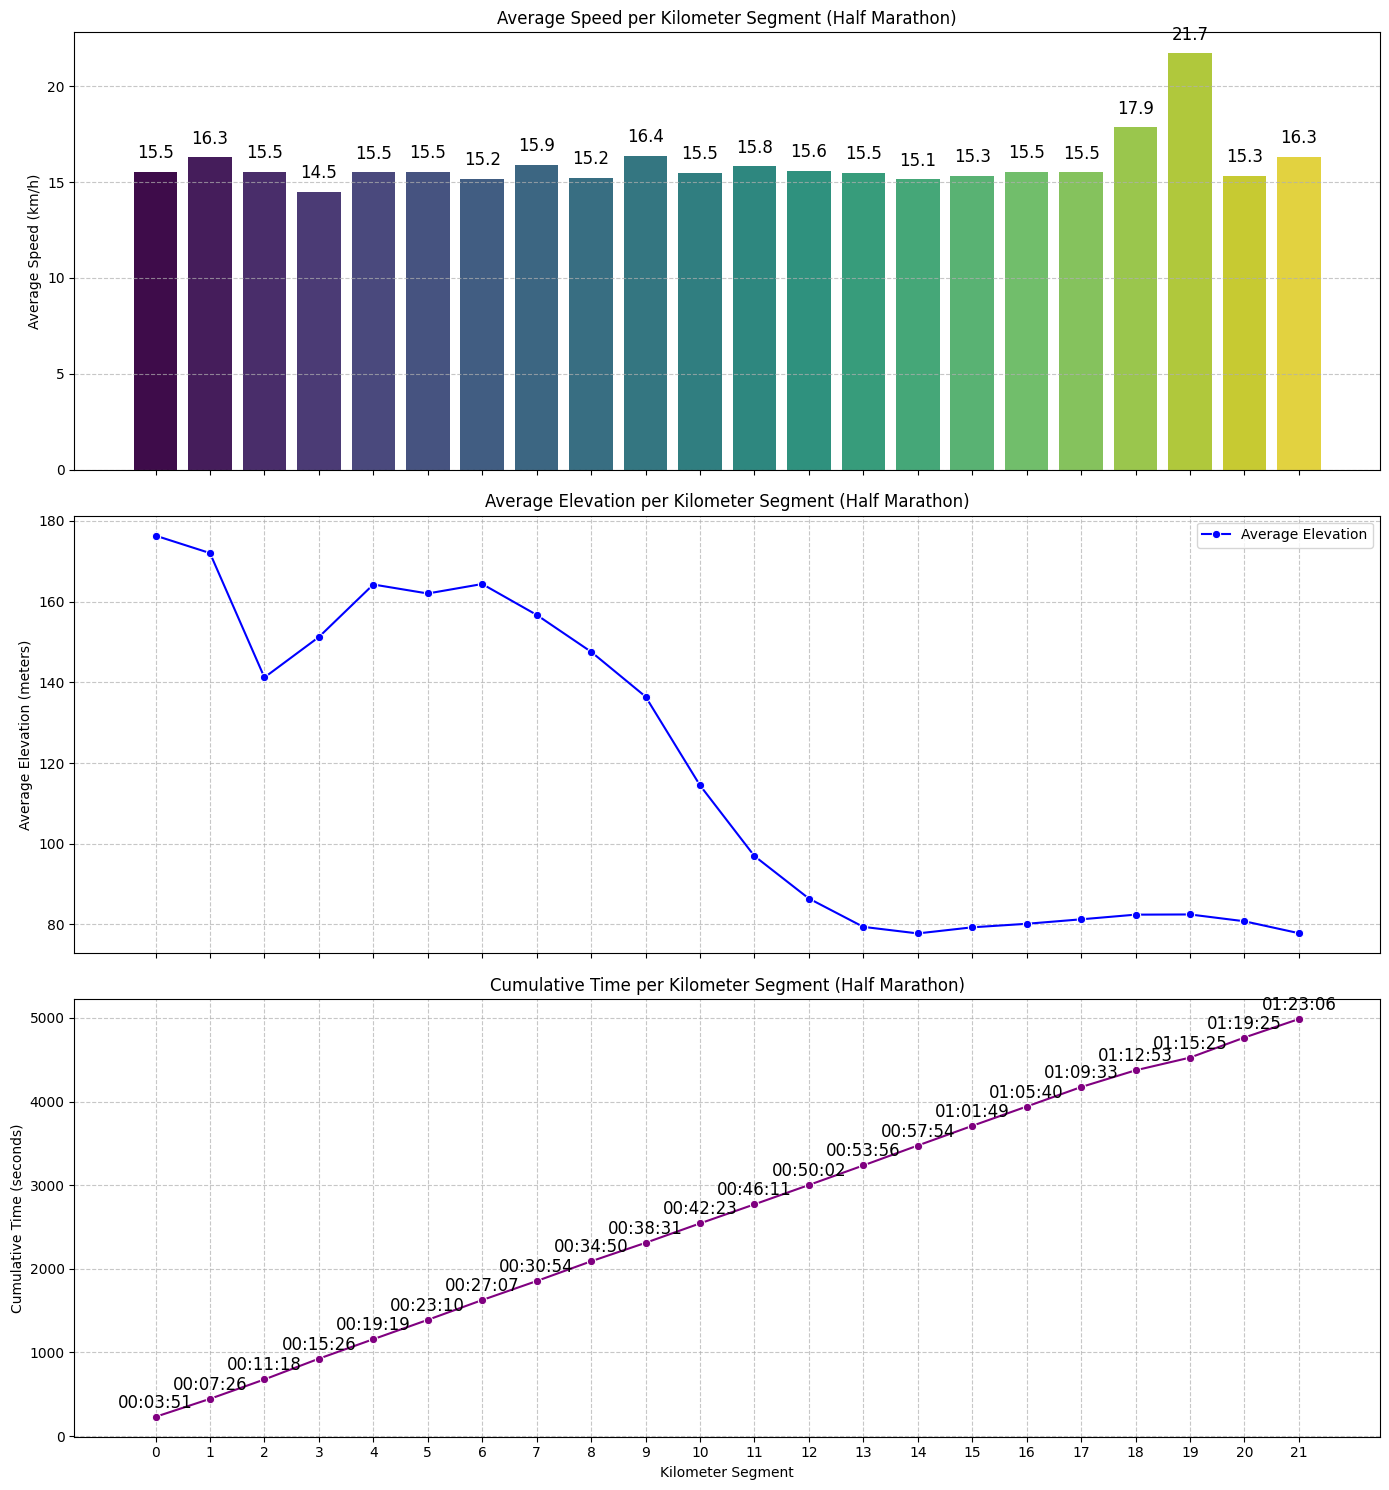

In [8]:
# Ensure these columns exist for plotting, in case previous cells were not run or state was reset
if 'cumulative_time_seconds' not in aggregated_data.columns:
    aggregated_data['cumulative_time_seconds'] = aggregated_data['total_time_seconds'].cumsum()

# Create a figure with two subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True) # Changed to 3 subplots

# Subplot 1: Average Speed per Kilometer Segment
sns.barplot(x=aggregated_data['kilometer_segment'], y='avg_speed_kmh', data=aggregated_data, palette='viridis', ax=axes[0], hue='kilometer_segment', legend=False)
axes[0].set_title('Average Speed per Kilometer Segment (Half Marathon)')
axes[0].set_ylabel('Average Speed (km/h)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Add speed values as text labels on bars for the first subplot
for index, row in aggregated_data.iterrows():
    axes[0].text(row['kilometer_segment'], # x coordinate (center of the bar)
                 row['avg_speed_kmh'] + 0.5, # y coordinate (numerical value slightly above the bar)
                 f"{row['avg_speed_kmh']:.1f}", # text string to display
                 color='black', ha="center", va='bottom', fontsize=12)

# Subplot 2: Average Elevation per Kilometer Segment
sns.lineplot(x=aggregated_data['kilometer_segment'], y='avg_elevation', data=aggregated_data, marker='o', color='blue', ax=axes[1], label='Average Elevation')
axes[1].set_title('Average Elevation per Kilometer Segment (Half Marathon)')
axes[1].set_ylabel('Average Elevation (meters)')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

# Subplot 3: Cumulative Time per Kilometer Segment
sns.lineplot(x=aggregated_data['kilometer_segment'], y='cumulative_time_seconds', data=aggregated_data, marker='o', color='purple', ax=axes[2])
axes[2].set_title('Cumulative Time per Kilometer Segment (Half Marathon)')
axes[2].set_xlabel('Kilometer Segment')
axes[2].set_ylabel('Cumulative Time (seconds)')
axes[2].grid(True, linestyle='--', alpha=0.7)

# Add cumulative time in HH:MM:SS format as text labels on points for the third subplot
for index, row in aggregated_data.iterrows():
    # Convert cumulative time to HH:MM:SS format
    cumulative_seconds = row['cumulative_time_seconds']
    hours = int(cumulative_seconds // 3600)
    minutes = int((cumulative_seconds % 3600) // 60)
    remaining_seconds = int(cumulative_seconds % 60)
    time_str = f"{hours:02d}:{minutes:02d}:{remaining_seconds:02d}"
    axes[2].text(row['kilometer_segment'], row['cumulative_time_seconds'] + 60,
            time_str, color='black', ha="center", va='bottom', fontsize=12)

# DO NOT CALL plt.show() here. It will be called in the next cell after annotations.
plt.tight_layout()

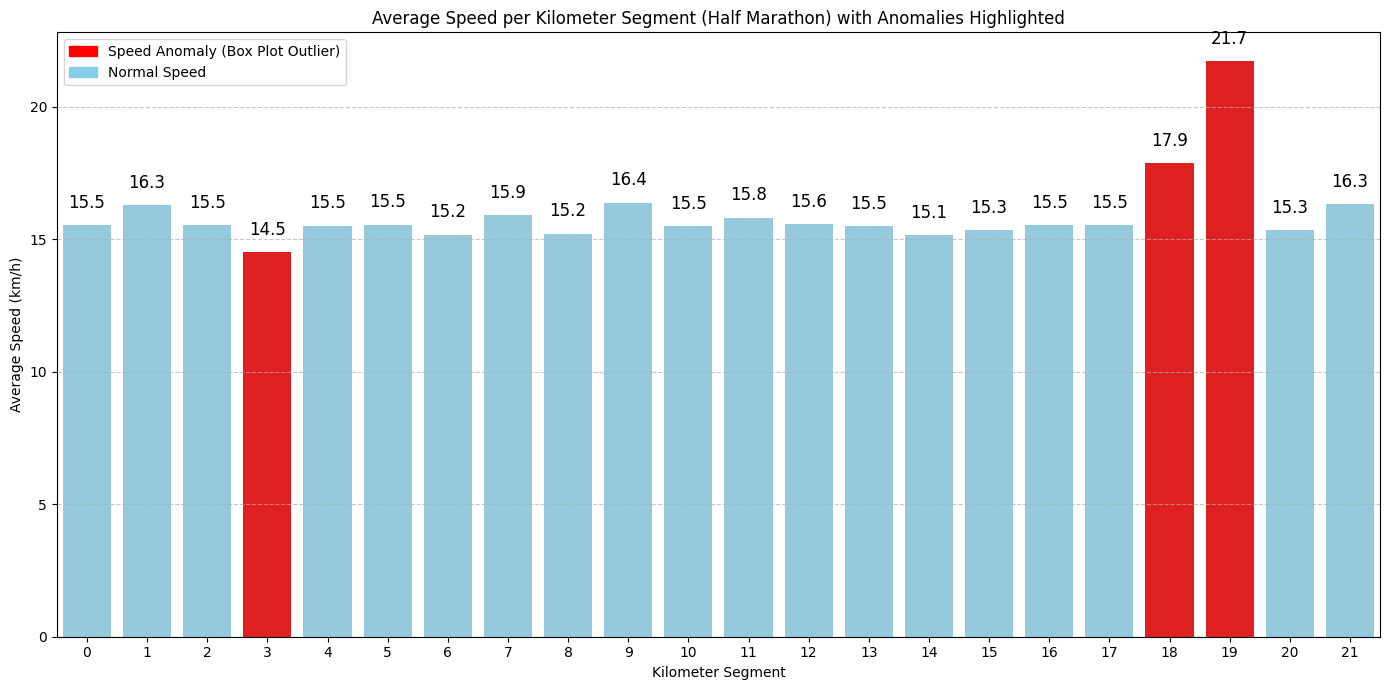

In [9]:
# Create a new figure and axes specifically for the Average Speed plot
plt.figure(figsize=(14, 7))
ax_speed = plt.gca() # Get current axes for the new plot

# Create a color palette based on whether a segment is an anomaly
# To address FutureWarning, assign the `is_speed_anomaly` to `hue` and set `legend=False`
sns.barplot(x=aggregated_data['kilometer_segment'], y='avg_speed_kmh', data=aggregated_data,
            hue=aggregated_data['is_speed_anomaly'], palette={True: 'red', False: 'skyblue'}, ax=ax_speed, legend=False)

ax_speed.set_title('Average Speed per Kilometer Segment (Half Marathon) with Anomalies Highlighted')
ax_speed.set_ylabel('Average Speed (km/h)')
ax_speed.grid(axis='y', linestyle='--', alpha=0.7)
ax_speed.set_xlabel('Kilometer Segment')

# Add speed values as text labels on bars
for index, row in aggregated_data.iterrows():
    ax_speed.text(row['kilometer_segment'],
                 row['avg_speed_kmh'] + 0.5,
                 f"{row['avg_speed_kmh']:.1f}",
                 color='black', ha="center", va='bottom', fontsize=12)

# Add a custom legend to explain anomaly colors
import matplotlib.patches as mpatches
anomaly_patch = mpatches.Patch(color='red', label='Speed Anomaly (Box Plot Outlier)')
normal_patch = mpatches.Patch(color='skyblue', label='Normal Speed')
ax_speed.legend(handles=[anomaly_patch, normal_patch], loc='upper left')

# Display the new plot
plt.tight_layout()
plt.show()

### Interactive Map Visualization of the GPX Track with Anomalies

To provide a geographical context for the analysis, an interactive map is generated using `folium`. The GPX track of the run is plotted, and specific kilometer segments identified as speed anomalies are highlighted in red. This allows for easy identification of the physical locations where unusual speed patterns occurred, which can be correlated with terrain or external factors. Tooltips provide details about the segment and anomaly type upon hovering.

In [10]:
# Install folium if not already installed
!pip install folium

In [ ]:
import folium

# Get the starting coordinates for centering the map
start_lat = df.iloc[0]['latitude']
start_lon = df.iloc[0]['longitude']

# Create a Folium map centered at the start of the track
m = folium.Map(location=[start_lat, start_lon], zoom_start=13)

# Extract latitude and longitude for the entire GPX track
points = df[['latitude', 'longitude']].values.tolist()

# Add the GPX track as a polyline to the map
folium.PolyLine(points, color='blue', weight=5, opacity=0.7).add_to(m)

# Add markers for anomaly segments
for index, row in aggregated_data[aggregated_data['is_speed_anomaly']].iterrows():
    # Find the data points for the current anomaly segment
    segment_df = df[df['kilometer_segment'] == row['kilometer_segment']]

    if not segment_df.empty:
        # Extract the latitude and longitude points for this specific segment
        anomaly_segment_points = segment_df[['latitude', 'longitude']].values.tolist()

        # Create a popup message for the segment
        tooltip_text = f"Segment: {int(row['kilometer_segment'])} km<br>Avg Speed: {row['avg_speed_kmh']:.2f} km/h<br>Anomaly: Speed Outlier"

        # Add the anomaly segment as a red polyline to the map
        folium.PolyLine(
            anomaly_segment_points,
            color='red',
            weight=8, # Make anomaly lines thicker for visibility
            opacity=1,
            tooltip=tooltip_text # Use tooltip for interactive info
        ).add_to(m)

# Display the map
# Note: To view the interactive map, access this notebook via nbviewer:
# https://nbviewer.org/github/SafouanEss/running-telemetry-analytics/blob/main/colab/Half_Marathon_performance_analysis__GPX_logs.ipynb
# GitHub renders notebooks as static HTML and blocks the JavaScript required to
# display interactive maps for security reasons.

![GPS drift on the Toronto Half Marathon track around km 18–19](Half_Marathon_Toronto_GPS_drift.png)

### Explanation of Identified Speed Anomalies:

Based on the Box Plot method, the following kilometer segments have been identified as speed anomalies:

*   **Kilometer Segment 3**: This segment shows a lower-than-average speed. Based on the race's route, this anomaly is due to **increasing elevation**, which naturally causes a reduction in speed.
*   **Kilometer Segments 18 and 19**: These segments show significantly higher speeds, flagged as outliers. Based on the race's route, these anomalies are attributed to **GPS drift**, which can cause inaccuracies in distance and time measurements, leading to an artificially inflated speed calculation for those specific segments.

## Summary:

### Data Analysis Key Findings

*   **GPX Data Processing**: The GPX file was successfully loaded, filtered to precisely 22 kilometers, and feature-engineered to include `time_diff`, `distance_diff`, `cumulative_distance`, `speed`, and `avg_elevation` for approximately 4938 data points.
*   **Aggregated Speed and Elevation Analysis**: Data was aggregated by kilometer segment, providing average speed, average elevation, and total time for each kilometer. This gives a clear overview of performance and terrain interaction.
*   **Speed Anomaly Detection**: A Box Plot based anomaly detection method was implemented for average speed per kilometer, successfully identifying segments 3, 18 and 19 as anomalies. These anomalies are highlighted in the dedicated speed plot.
*   **Visualizations**: Key visualizations include average speed per kilometer (with anomalies highlighted), average elevation per kilometer, and cumulative time per kilometer, providing a clear overview of performance trends.

### Insights and Next Steps

*   **Focus on Aggregated Performance**: The notebook focuses on aggregated performance metrics per kilometer, providing a streamlined overview of the half marathon, incorporating both speed and elevation.
*   **Simplified Presentation**: The analysis is more concise and directly addresses the primary goal of understanding overall race performance.
*   **Targeted Anomaly Detection**: The anomaly detection specifically highlights significant deviations in speed, providing actionable insights into unusual performance segments.
*   **Potential Future Enhancements**: For real-time applications or more nuanced analysis of high-frequency data, the underlying data processing could significantly benefit from advanced smoothing techniques for streaming data, potentially implemented within a cloud-native environment to handle scale and real-time ingestion.

